# MGWR on HIV 
***
This notebook utilizes the python implementation of multi-scale geographically weighted regression (mgwr), a spatial statistical technique that builds upon the traditional global regression model (OLS) and geographically weighted regression (gwr) to model the correlations between HIV rates at zip code level and social-demographic variables.

## Notebook outline
- [Preprocessing](#Preprocessing) 
- [Multicollinearity](#Multicollinearity)
- [GWR model fit](#GWR)
- [MGWR model fit](#MGWR)
- [Visualizations](#Visualizations)
- [References](#References)

<a id = 'Preprocessing'></a>
## Preprocessing
In the preprocessing part, we merge the US shapefile data by zipcode (for the latitudes and longitudes), ACS (for the independent variables), and HIV data (for the dependent variable -- either HIV rate or cases).

In [402]:
# !pip install mgwr
# !pip install matplotlib_scalebar

In [403]:
import numpy as np
import pandas as pd
import libpysal as ps
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import compare_surfaces, truncate_colormap
import geopandas as gp
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
import seaborn as sns
import shapefile as shp

from matplotlib_scalebar.scalebar import ScaleBar


In [404]:
# set parameters here
city = 'Dallas'
X = ['% unemployed', '% white', '% vacant housing', '% without health insurance']
y = 'Zip Code Rate'


In [405]:
# US by zipcode shapefile data
shape = gp.read_file('data/US_shapefile/tl_2016_us_zcta510.shp')
shape.head()

,ZCTA5CE10,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,43451,43451,B5,G6350,S,63411475,157689,+41.3183010,-083.6174935,"POLYGON ((-83.67446 41.33112, -83.67444 41.331..."
1,43452,43452,B5,G6350,S,121783676,13437380,+41.5157923,-082.9809454,"POLYGON ((-83.06775 41.53772, -83.06773 41.539..."
2,43456,43456,B5,G6350,S,9389362,999166,+41.6468445,-082.8226641,"MULTIPOLYGON (((-82.85660 41.68122, -82.85683 ..."
3,43457,43457,B5,G6350,S,48035540,0,+41.2673266,-083.4274645,"POLYGON ((-83.46747 41.26819, -83.46760 41.268..."
4,43458,43458,B5,G6350,S,2573816,39915,+41.5304461,-083.2133648,"POLYGON ((-83.22229 41.53102, -83.22228 41.532..."


In [406]:
# ACS data
ACS = pd.read_csv('data/ACS_2018_5year__zipcode_US_byZipcode_normalized.csv', encoding = 'unicode_escape')
ACS['GEOID'] = ACS['GEOID'].astype(int)
ACS.head()

,GEOID,Median monthly housing costs,% unemployed,% manufacturing,% structures more than 30 years old,% households moved <10 years ago,% > 60 years old,% service industry,% vacant housing,% owner occupied housing,...,"% housing units 1-unit, detached","% housing units 1-unit, attached",% housing units 2 units,% housing units 3 or 4 units,% housing units 5 to 9 units,% housing units 10 to 19 units,% housing units 20 or more units,% housing units mobile home,"% housing units boat, rv, van, etc",% housing units two or more
0,601,203,21.732314,7.674486,46.348941,25.546170,24.364923,23.110339,23.118729,54.558637,...,81.814381,10.437570,0.933668,2.146042,2.424749,1.546823,0.459866,0.236901,0.0,5.086399
1,602,175,7.814260,8.991611,53.990691,16.453320,24.769783,26.459280,26.805723,74.430837,...,70.085617,2.499569,21.634201,3.861403,1.195196,0.103430,0.620583,0.000000,0.0,26.219617
2,603,261,10.998628,11.756802,52.190366,31.781678,26.160528,21.531743,20.887664,57.983674,...,66.352680,15.433343,2.278804,1.978528,3.586854,6.618403,3.665008,0.086381,0.0,14.540743
3,606,129,5.614837,16.014760,52.004334,21.707963,25.710735,24.797048,27.266161,74.528302,...,87.323944,9.823041,0.216685,0.469484,1.227880,0.650054,0.000000,0.288913,0.0,1.336222
4,610,196,7.466749,20.319390,52.632003,18.158881,25.427548,23.942319,28.593309,76.699029,...,73.639661,4.820637,15.002015,2.466747,2.120113,0.951229,0.854494,0.145103,0.0,19.274486


*Change the city name here*

In [407]:
# HIV data
path = 'data/HIV data by city/' + city + '_AIDSVu_DownloadableDataset_2018.csv'
HIV = pd.read_csv(path, encoding = 'unicode_escape')
HIV.head()

,ï»¿City,City Name,Zip Code,Year,Zip Code Rate,Zip Code Rate Stability,Zip Code Cases,Male Rate,Male Rate Stability,Male Cases,...,Age 45-59 Rate Stability,Age 45-59 Cases,Age 60+ Rate,Age 60+ Rate Stability,Age 60+ Cases,Gini Coefficient,Median Household Income,Percent Living in Poverty,Percent High School Education,Correctional Warning
0,Dallas,Dallas,75001.0,2018.0,967.0,Yes,106.0,1616.0,Yes,88.0,...,Yes,39.0,532.0,No,7.0,0.405,73094.0,10.1,95.2,1.0
1,Dallas,Dallas,75006.0,2018.0,549.0,Yes,206.0,957.0,Yes,176.0,...,Yes,87.0,511.0,Yes,33.0,0.423,61844.0,12.5,78.9,1.0
2,Dallas,Dallas,75019.0,2018.0,172.0,Yes,53.0,308.0,Yes,46.0,...,No,11.0,283.0,No,10.0,0.415,121279.0,3.2,97.3,1.0
3,Dallas,Dallas,75038.0,2018.0,1024.0,Yes,230.0,1632.0,Yes,183.0,...,Yes,68.0,1018.0,Yes,19.0,0.449,56636.0,15.1,91.6,1.0
4,Dallas,Dallas,75039.0,2018.0,1017.0,Yes,101.0,1850.0,Yes,93.0,...,Yes,30.0,-1.0,No,-1.0,0.388,90961.0,4.3,98.2,1.0


In [408]:
# merge the HIV and ACS data by geoid & zipcode
df = pd.merge(HIV, ACS, left_on = 'Zip Code', right_on = 'GEOID')
df = df[df['Zip Code Rate'] != -1]


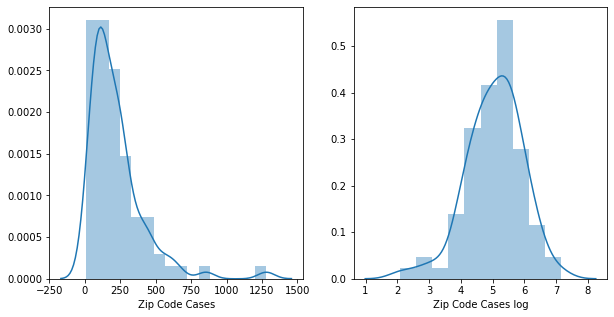

In [409]:
# log transform cases at zip code level
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.distplot(df['Zip Code Cases'], ax = axes[0])

df['Zip Code Cases log'] = np.log(df['Zip Code Cases'])
sns.distplot(df['Zip Code Cases log'], ax = axes[1])


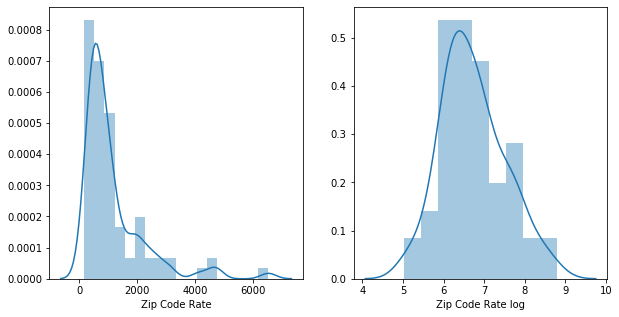

In [410]:
# log transform rates at zip code level
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.distplot(df['Zip Code Rate'], ax = axes[0])

df['Zip Code Rate log'] = np.log(df['Zip Code Rate'])
sns.distplot(df['Zip Code Rate log'], ax = axes[1])


In [411]:
# convert GEOID10 (used as an ID for each zipcode area) from string to int
def str_to_int(x):
    return int(x)
shape["GEOID10"] = shape["GEOID10"].apply(str_to_int)

In [412]:
# convert the latitudes and longitudes from string to float
def str_to_float(x):
    if (x[0] == '+'):
        x = float(x[1:])
        return x
    else:
        x = float(x[2:])
        return x
shape['INTPTLAT10'] = shape['INTPTLAT10'].apply(str_to_float)
shape['INTPTLON10'] = shape['INTPTLON10'].apply(str_to_float)

In [413]:
# merge the df and shapefile data by zip code & geoid
df = pd.merge(df, shape, left_on = 'Zip Code', right_on = 'GEOID10')

In [414]:
df.head()

,ï»¿City,City Name,Zip Code,Year,Zip Code Rate,Zip Code Rate Stability,Zip Code Cases,Male Rate,Male Rate Stability,Male Cases,...,ZCTA5CE10,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,Dallas,Dallas,75001.0,2018.0,967.0,Yes,106.0,1616.0,Yes,88.0,...,75001,75001,B5,G6350,S,9929852,8702,32.960047,96.838522,"POLYGON ((-96.83860 32.96023, -96.83859 32.960..."
1,Dallas,Dallas,75006.0,2018.0,549.0,Yes,206.0,957.0,Yes,176.0,...,75006,75006,B5,G6350,S,43706561,657534,32.962141,96.898585,"POLYGON ((-96.94199 32.96818, -96.94192 32.968..."
2,Dallas,Dallas,75019.0,2018.0,172.0,Yes,53.0,308.0,Yes,46.0,...,75019,75019,B5,G6350,S,42675389,4656989,32.963417,96.984664,"POLYGON ((-97.02506 32.97737, -97.02112 32.980..."
3,Dallas,Dallas,75038.0,2018.0,1024.0,Yes,230.0,1632.0,Yes,183.0,...,75038,75038,B5,G6350,S,34641368,105488,32.874776,96.996862,"POLYGON ((-97.03312 32.87532, -97.03310 32.876..."
4,Dallas,Dallas,75039.0,2018.0,1017.0,Yes,101.0,1850.0,Yes,93.0,...,75039,75039,B5,G6350,S,13608195,888383,32.885608,96.942654,"POLYGON ((-96.95864 32.90516, -96.95832 32.905..."


In [415]:
df = gp.GeoDataFrame(df)

In [416]:
path = 'data/' + city + '_GWR.shp'
df.to_file(path)

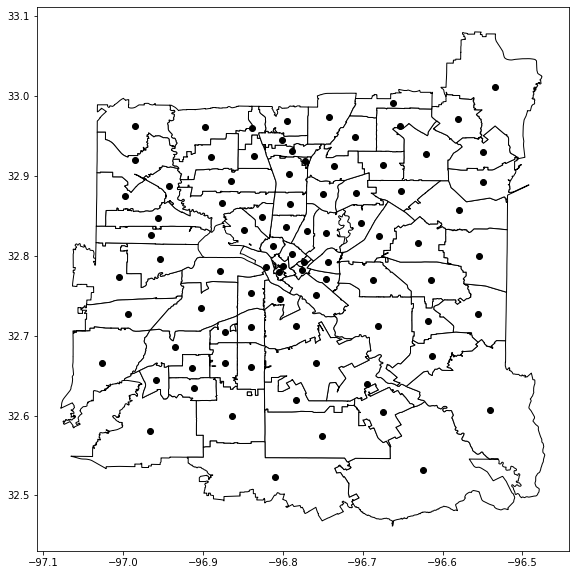

In [417]:
# check to see that the map looks good with the dots representing the center of a unit area
fig, ax = plt.subplots(figsize = (10,10))
df.plot(ax=ax, **{'edgecolor':'black', 'facecolor':'white'})
df.centroid.plot(ax=ax, c='black')

<a id = 'GWR'></a>
## GWR model fit ##

In [418]:
y = y + ' log'
g_y = df[y].values.reshape((-1, 1))

In [419]:
g_X = df[X].values

In [420]:
g_X = (g_X - g_X.mean(axis = 0)) / g_X.std(axis = 0)
g_y = (g_y - g_y.mean(axis = 0)) / g_y.std(axis = 0)


In [421]:
g_coords = list(zip(df['INTPTLON10'], df['INTPTLAT10']))

In [422]:
gwr_selector = Sel_BW(g_coords, g_y, g_X, spherical = True)
gwr_bw = gwr_selector.search()
gwr_model = GWR(g_coords, g_y, g_X, gwr_bw)
gwr_results = gwr_model.fit()

In [423]:
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                  85
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                             33.664
Log-likelihood:                                                     -81.245
AIC:                                                                172.491
AICc:                                                               175.568
BIC:                                                               -321.748
R2:                                                                   0.604
Adj. R2:                                                              0.584

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

<a id = 'MGWR'></a>
## MGWR model fit ##

In [424]:
# we fit the model here, need to make sure multi is set to true sicne we are using
# MGWR and spherical set to true since we are using lats/lons, otherwise if the coordinates
# are actual distances we need to set it false since they are projected

mgwr_selector = Sel_BW(g_coords, g_y, g_X, multi = True, spherical = True)
mgwr_bw = mgwr_selector.search()
mgwr_results = MGWR(g_coords, g_y, g_X, mgwr_selector).fit()
print(mgwr_bw)


[44. 83. 83. 83. 44.]


In [425]:
mgwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                  85
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                             33.664
Log-likelihood:                                                     -81.245
AIC:                                                                172.491
AICc:                                                               175.568
BIC:                                                               -321.748
R2:                                                                   0.604
Adj. R2:                                                              0.584

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

<a id = 'Visualizations'></a>
## Visualizations

Now that the MGWR results are ready to be visualized. To do this, we add the coefficients (beta) from the MGWR summary as a column to the dataframe. We will also only consider a unit area with t value larger than its corresponding threshold, otherwise the coefficient is not considered statistically significant enough.

**prepare the data columns**

In [426]:
# add a column for correlation coefficient and a column for local t values
df['beta_intercept'] = mgwr_results.params[:, 0]
df['t_intercept'] = mgwr_results.tvalues[:, 0]
i = 1
for x in X:
    df['beta_' + x] = mgwr_results.params[:, i]
    df['t_' + x] = mgwr_results.tvalues[:, i]
    i += 1
    

In [427]:
# a call to filter_tvals() to keep t values bigger than the thresholds, otherwse 0
mgwr_filtered_t = mgwr_results.filter_tvals()
for i in range(len(mgwr_filtered_t)):
    for j in range(len(mgwr_filtered_t[i])):
        if (mgwr_filtered_t[i][j] != 0):
            mgwr_filtered_t[i][j] = 1

In [428]:
# filter out statistically insignificant local coefficients
df['bt_intercept'] = df['beta_intercept'].values * mgwr_filtered_t[:, 0]
i = 1
for x in X:
    df['bt_' + x] = df['beta_' + x].values * mgwr_filtered_t[:, i]
    i += 1

In [429]:
df.head()

,ï»¿City,City Name,Zip Code,Year,Zip Code Rate,Zip Code Rate Stability,Zip Code Cases,Male Rate,Male Rate Stability,Male Cases,...,t_% white,beta_% vacant housing,t_% vacant housing,beta_% without health insurance,t_% without health insurance,bt_intercept,bt_% unemployed,bt_% white,bt_% vacant housing,bt_% without health insurance
0,Dallas,Dallas,75001.0,2018.0,967.0,Yes,106.0,1616.0,Yes,88.0,...,-3.321899,0.590022,7.356345,0.278016,2.491423,0.0,-0.203956,-0.274713,0.590022,0.000000
1,Dallas,Dallas,75006.0,2018.0,549.0,Yes,206.0,957.0,Yes,176.0,...,-3.225741,0.596621,7.369796,0.301517,2.759303,0.0,-0.202498,-0.266766,0.596621,0.301517
2,Dallas,Dallas,75019.0,2018.0,172.0,Yes,53.0,308.0,Yes,46.0,...,-3.101533,0.607501,7.481998,0.301162,2.636249,-0.0,-0.000000,-0.256346,0.607501,0.301162
3,Dallas,Dallas,75038.0,2018.0,1024.0,Yes,230.0,1632.0,Yes,183.0,...,-3.184174,0.607513,7.597765,0.199035,1.682839,0.0,-0.209108,-0.255693,0.607513,0.000000
4,Dallas,Dallas,75039.0,2018.0,1017.0,Yes,101.0,1850.0,Yes,93.0,...,-3.204832,0.599324,7.415485,0.227084,2.076355,0.0,-0.212108,-0.259239,0.599324,0.000000


**visualizations**

In [430]:
# customized map function
def mapp(col, name, title, size, positive, normal = False):
    if (positive == 1):
        color = 'Blues'
    elif (positive == 0):
        color = 'Reds_r'
    elif (positive == 2):
        color = 'RdBu'

    figsize = (14,10)
    colors = 10
    colors = 6
    fig, ax = plt.subplots(1, figsize = (size, size))

    col.plot(column = name, ax = ax,cmap = color, figsize = figsize, k = colors, linewidth = 0.5)

    ax.axis("off")

    Scalebar = ScaleBar(100000, location = 'lower left') # 1 pixel = 0.2 meter
    print(ax.collections)
    scatter = ax.collections[-1]

    plt.colorbar(scatter, ax = ax, extend = 'min', orientation = 'horizontal', fraction = 0.046, pad = 0.04)
    col.boundary.plot(ax = ax, color = 'grey', alpha = 0.2)
   
    plt.title(title)
    plt.show()

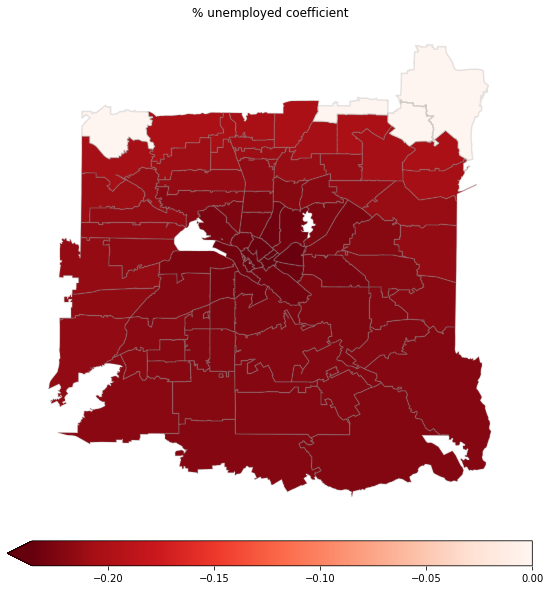

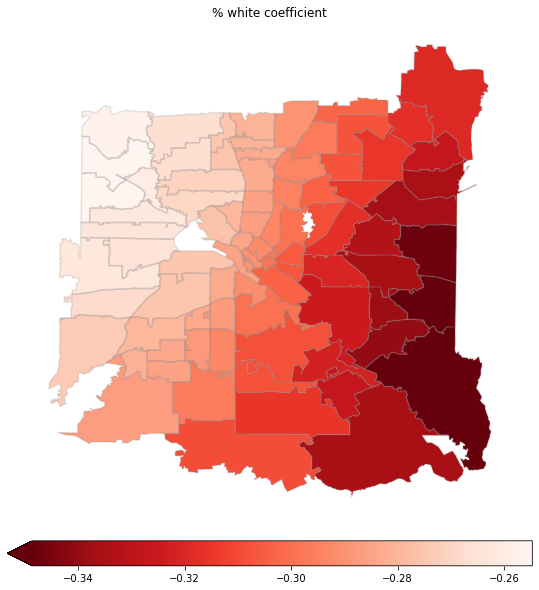

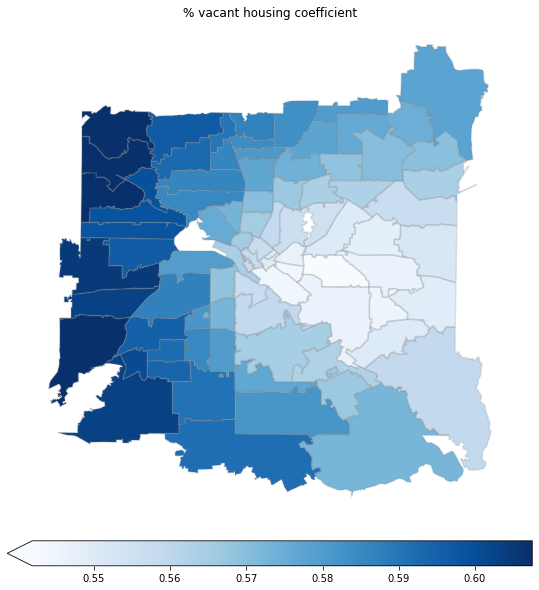

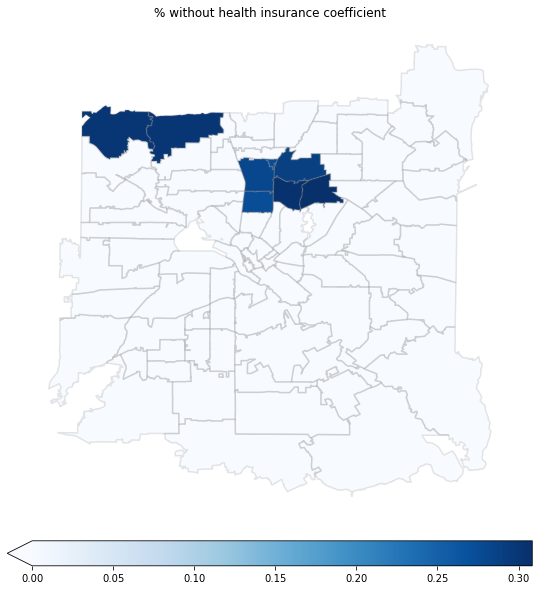

In [431]:
# automatically set the color schemes for the maps
# we use blue for positive correlations and red for negative correlations
p = -1
for x in X:
    for i in df['bt_' + x].values:
        if (p == 0 and i > 0):
            p = 2
            break
        elif (p == 1 and i < 0):
            p = 2
            break
        elif (i > 0):
            p = 1
        elif (i < 0):
            p = 0
    mapp(col = df,name = 'bt_' + x, title = x + ' coefficient', size = 10, positive = p, normal = False)
    p = -1

<a id = 'Multicollinearity'></a>
## Multicollinearity
One assumption for the regression models in general is that there is not a significant level of correlations among explanatory variables, otherwise it would be hard to distinguish the contribution of each variable. A commonly used criteria is variance inflation factors (VIF) that measures how much the variance of a variable increases due to collinearity. Typically a VIF value over 10 is considered high. However, there is no hard thresholds to determine how much of a colinearity is problematic and the rules are not absolute. (Oshan et al., 2019) 

In [432]:
# Import library for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [433]:
# table to show the global VIF values among dependent variables
df_independent = df[X]
vif_table = calc_vif(df_independent)
vif_table

,variables,VIF
0,% unemployed,5.810132
1,% white,5.491993
2,% vacant housing,5.011887
3,% without health insurance,6.115450


Text(0.5, 1, 'local condition numbers')

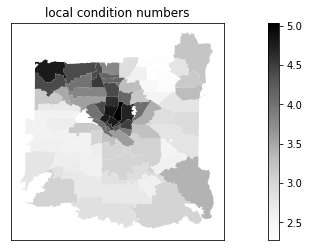

In [434]:
# visualize CN values at local unit areas
df['lcn'] = gwr_results.local_collinearity()[2]
fig, ax = plt.subplots(1, 1, figsize = (16, 4))
df.plot('lcn', ax = ax, cmap = 'Greys', legend = True)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_title('local condition numbers')


## References
Oshan, T., Li, Z., Kang, W., Wolf, L., &amp; Fotheringham, A. (2019). mgwr: A Python Implementation of Multiscale Geographically Weighted Regression for Investigating Process Spatial Heterogeneity and Scale. ISPRS International Journal of Geo-Information, 8(6), 269. https://doi.org/10.3390/ijgi8060269 